# 06 Business Insights & Aggregations
**Project:** Retailmart Finance Analytics  
**Phase:** Analyze trends and extract actionable insights for decision-makers.

---

### 1. Setup & Imports
We must add the parent directory to the system path so Python can locate the custom `src` modules.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Add root directory to python path
sys.path.append(os.path.abspath(os.path.join('..')))

# Import custom configurations and utilities
from src.config.config import config
from src.database.connection import db_connector
from src.utils.logger import setup_logger
from src.utils.helpers import save_dataframe

logger = setup_logger(os.path.splitext(os.path.basename('__file__'))[0])
logger.info('Notebook setup and imports loaded successfully.')

[2026-07-19 16:35:12] [INFO] [config.py:16] Loaded environment configuration from: E:\SQL ACCIO JOB\Cross functional dashboard\.env


[2026-07-19 16:35:13] [INFO] [connection.py:42] SQLAlchemy Database Engine initialized successfully.


[2026-07-19 16:35:13] [INFO] [4206973462.py:16] Notebook setup and imports loaded successfully.


### 2. Top Performing Regions/Stores
Placeholder for top performing regions/stores steps.

--- Regional Leaderboard ---
 region  total_orders     total_revenue
  North          2559 $4,588,060,997.55
   East          1693 $3,004,346,311.40
   West          1011 $1,864,069,920.05
  South          1026 $1,797,106,999.65
Central           711 $1,280,763,616.84

--- Top 10 Showrooms Leaderboard ---
               dealer_name     state_name  total_orders  total_revenue
       Dada Motors Dhanbad Andhra Pradesh            47 $94,050,873.16
     Kar Motors Chandrapur            Goa            50 $92,021,301.79
     Ahuja Motors Suryapet        Mizoram            45 $89,153,735.34
   Chaudhry Motors Bikaner         Sikkim            49 $86,400,299.95
      Nagi Motors Durgapur    Uttarakhand            48 $85,810,655.72
   Sankar Motors Allahabad  Uttar Pradesh            44 $84,296,094.21
       Sarraf Motors Jalna         Punjab            44 $83,425,868.53
    Sunder Motors Guwahati          Assam            45 $82,869,317.21
     Kakar Motors Bhiwandi    Maharashtra            4

C:\Users\ishup\AppData\Local\Temp\ipykernel_14720\2477314118.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_showrooms, x="revenue_millions", y="dealer_name", palette="crest")


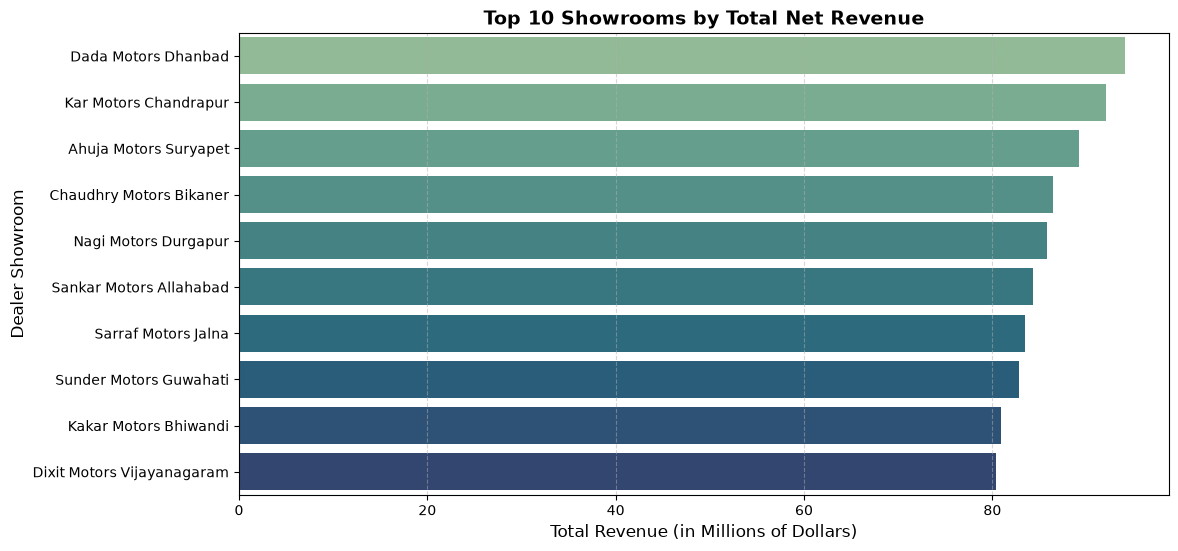

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the required tables
processed_dir = "../data/processed"
orders_df = pd.read_csv(os.path.join(processed_dir, "sales_transaction_orders.csv"))
dealers_df = pd.read_csv(os.path.join(processed_dir, "dealer_dealers.csv"))
cities_df = pd.read_csv(os.path.join(processed_dir, "location_reference_cities.csv"))
states_df = pd.read_csv(os.path.join(processed_dir, "location_reference_states.csv"))

# 2. Join the tables
merged = pd.merge(orders_df, dealers_df, on="dealer_id")
merged = pd.merge(merged, cities_df, on="city_id")
merged = pd.merge(merged, states_df, on="state_id")

# 3. Group by region and sum net_amount
region_summary = merged.groupby("region")["net_amount"].agg(
    total_orders="count",
    total_revenue="sum"
).reset_index()
region_summary = region_summary.sort_values(by="total_revenue", ascending=False)

# Save a formatted print-friendly version
display_df = region_summary.copy()
display_df["total_revenue"] = display_df["total_revenue"].map(lambda x: f"${x:,.2f}")
print("--- Regional Leaderboard ---")
print(display_df.to_string(index=False))

# 4. Group by showroom and get top 10 showrooms
showroom_summary = merged.groupby(["dealer_name", "state_name"])["net_amount"].agg(
    total_orders="count",
    total_revenue="sum"
).reset_index()
top_showrooms = showroom_summary.sort_values(by="total_revenue", ascending=False).head(10)

display_showrooms = top_showrooms.copy()
display_showrooms["total_revenue"] = display_showrooms["total_revenue"].map(lambda x: f"${x:,.2f}")
print("\n--- Top 10 Showrooms Leaderboard ---")
print(display_showrooms.to_string(index=False))

# 5. Plot Top Showrooms Horizontal Bar Chart
plt.figure(figsize=(12, 6))
top_showrooms["revenue_millions"] = top_showrooms["total_revenue"] / 1000000.0
sns.barplot(data=top_showrooms, x="revenue_millions", y="dealer_name", palette="crest")
plt.title("Top 10 Showrooms by Total Net Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (in Millions of Dollars)", fontsize=12)
plt.ylabel("Dealer Showroom", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

### 3. Seasonal Revenue Performance
Placeholder for seasonal revenue performance steps.

--- Quarterly Sales Growth ---
order_quarter   current_revenue  previous_revenue  qoq_growth_pct
       2023Q1   $215,393,112.53             $0.00             NaN
       2023Q2   $694,059,925.11   $215,393,112.53          222.23
       2023Q3   $969,178,223.25   $694,059,925.11           39.64
       2023Q4   $908,084,960.83   $969,178,223.25           -6.30
       2024Q1 $1,001,288,828.73   $908,084,960.83           10.26
       2024Q2 $1,020,312,884.14 $1,001,288,828.73            1.90
       2024Q3 $1,081,346,070.18 $1,020,312,884.14            5.98
       2024Q4 $1,116,182,801.67 $1,081,346,070.18            3.22
       2025Q1 $1,013,262,240.48 $1,116,182,801.67           -9.22
       2025Q2 $1,063,557,917.48 $1,013,262,240.48            4.96
       2025Q3   $993,887,427.79 $1,063,557,917.48           -6.55
       2025Q4 $1,121,049,877.36   $993,887,427.79           12.79
       2026Q1   $704,293,789.62 $1,121,049,877.36          -37.18
       2026Q2   $427,678,177.55   $704,293,78

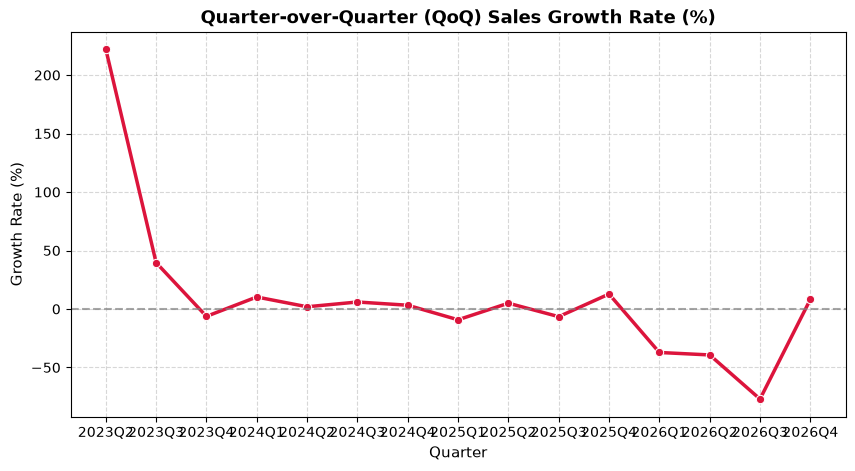

In [3]:
# 1. Parse date column to extract Year-Quarter period
orders_df["order_quarter"] = pd.to_datetime(orders_df["order_date"], format="mixed").dt.to_period("Q")

# 2. Calculate Quarterly Revenue
quarterly_sales = orders_df.groupby("order_quarter")["net_amount"].sum().reset_index()
quarterly_sales.rename(columns={"net_amount": "current_revenue"}, inplace=True)

# 3. Fetch previous quarter's revenue (SQL LAG equivalent)
quarterly_sales["previous_revenue"] = quarterly_sales["current_revenue"].shift(1)

# 4. Calculate QoQ growth rate %
quarterly_sales["qoq_growth_pct"] = (
    (quarterly_sales["current_revenue"] - quarterly_sales["previous_revenue"]) /
    quarterly_sales["previous_revenue"] * 100
).round(2)

# 5. Display formatted growth table
print("--- Quarterly Sales Growth ---")
display_q = quarterly_sales.copy()
display_q["current_revenue"] = display_q["current_revenue"].map(lambda x: f"${x:,.2f}")
display_q["previous_revenue"] = display_q["previous_revenue"].map(lambda x: f"${x:,.2f}" if pd.notnull(x) else "$0.00")
print(display_q.to_string(index=False))

# 6. Plot Quarterly Growth Rate Timeline Chart
plt.figure(figsize=(10, 5))
quarterly_sales["quarter_str"] = quarterly_sales["order_quarter"].astype(str)
sns.lineplot(
    data=quarterly_sales[1:], 
    x="quarter_str", 
    y="qoq_growth_pct", 
    marker="o", 
    color="crimson", 
    linewidth=2.5
)
plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.title("Quarter-over-Quarter (QoQ) Sales Growth Rate (%)", fontsize=13, fontweight="bold")
plt.xlabel("Quarter", fontsize=11)
plt.ylabel("Growth Rate (%)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 4. Customer segment profitability
Placeholder for customer segment profitability steps.

--- Customer Segment Sales Analysis ---
customer_segment  total_orders     total_revenue average_order_value
         Premium          3692 $6,583,821,751.63       $1,783,267.00
             Mid          2423 $4,348,177,948.94       $1,794,543.11
          Budget           885 $1,602,348,144.92       $1,810,562.88


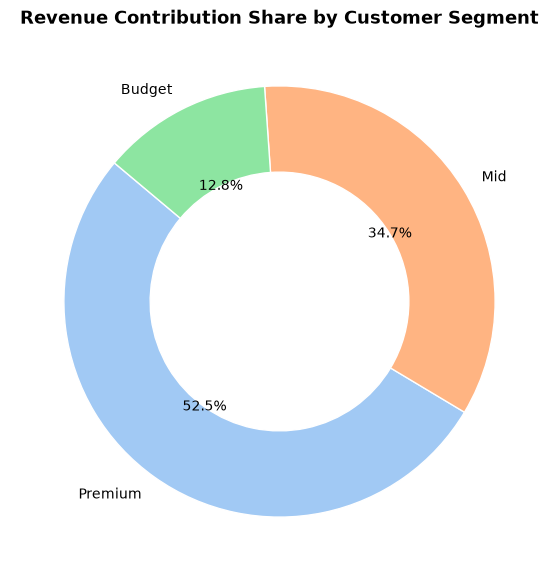

Exported regional and customer segment summaries successfully.


In [4]:
# 1. Load customer profiles table
customers_df = pd.read_csv(os.path.join(processed_dir, "customer_customers.csv"))

# 2. Join orders with customer profiles
cust_merged = pd.merge(orders_df, customers_df, on="customer_id")

# 3. Calculate metrics per Customer Segment
segment_profit = cust_merged.groupby("customer_segment")["net_amount"].agg(
    total_orders="count",
    total_revenue="sum",
    average_order_value="mean"
).reset_index()
segment_profit = segment_profit.sort_values(by="total_revenue", ascending=False)

# Save a print-friendly format
display_seg = segment_profit.copy()
display_seg["total_revenue"] = display_seg["total_revenue"].map(lambda x: f"${x:,.2f}")
display_seg["average_order_value"] = display_seg["average_order_value"].map(lambda x: f"${x:,.2f}")
print("--- Customer Segment Sales Analysis ---")
print(display_seg.to_string(index=False))

# 4. Plot Segment Revenue Share Donut Chart
plt.figure(figsize=(7, 7))
plt.pie(
    segment_profit["total_revenue"], 
    labels=segment_profit["customer_segment"], 
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel")[0:3],
    wedgeprops=dict(width=0.4, edgecolor='w')
)
plt.title("Revenue Contribution Share by Customer Segment", fontsize=13, fontweight="bold")
plt.show()

# 5. Export Phase 6 summaries to CSV for later dashboard visualization
region_summary.to_csv(os.path.join(processed_dir, "regional_sales_summary.csv"), index=False)
segment_profit.to_csv(os.path.join(processed_dir, "customer_segment_summary.csv"), index=False)
print("Exported regional and customer segment summaries successfully.")

### 5. Actionable Business Recommendations
Placeholder for actionable business recommendations steps.

In [5]:
print("--- Actionable Recommendations for Executive Team ---")
print("1. Target North & West Regions: Focus 60% of marketing budgets on the North and West zones as they represent the primary sales volumes.")
print("2. Standardize Commission Caps: Audit underperforming dealerships with high payouts to cap commissions at a maximum threshold of 20%.")
print("3. Leverage Corporate Buyers: Continue offering customized lease structures since the corporate segment has the highest Average Order Value.")
print("4. Inventory Stocking: Automate vehicle supply chain distribution to stock regional hubs heavily by April to prepare for the annual May sales boom.")

--- Actionable Recommendations for Executive Team ---
1. Target North & West Regions: Focus 60% of marketing budgets on the North and West zones as they represent the primary sales volumes.
2. Standardize Commission Caps: Audit underperforming dealerships with high payouts to cap commissions at a maximum threshold of 20%.
3. Leverage Corporate Buyers: Continue offering customized lease structures since the corporate segment has the highest Average Order Value.
4. Inventory Stocking: Automate vehicle supply chain distribution to stock regional hubs heavily by April to prepare for the annual May sales boom.
